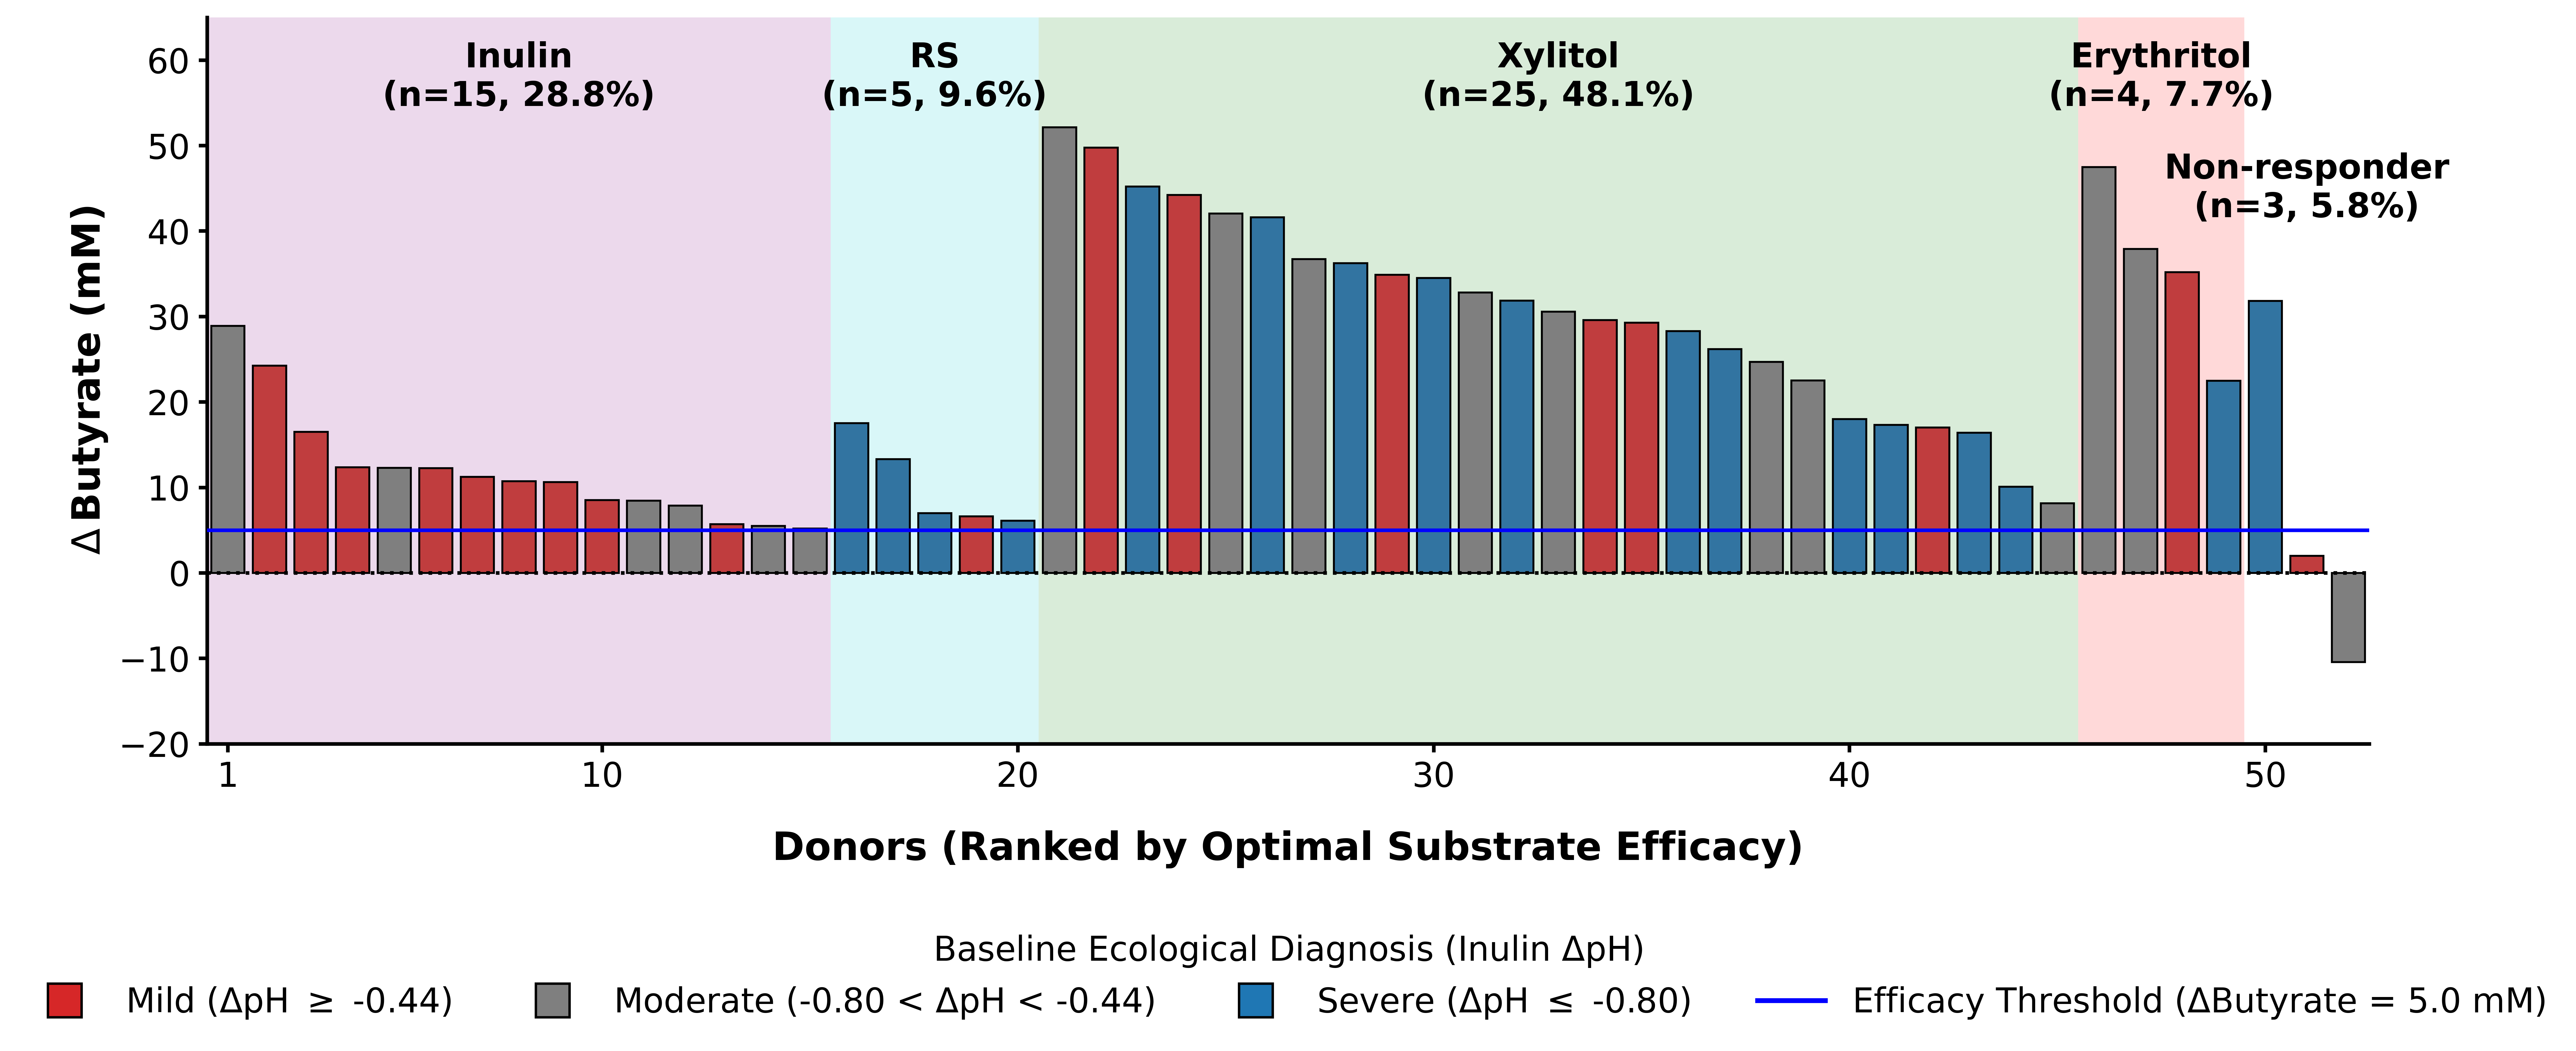

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Publication-Quality Visualization Settings
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

DPI_SETTING = 600
EFFICACY_THRESHOLD = 5.0

# =============================================================================
# 2. Data Loading and Preprocessing
# =============================================================================
def load_and_calc_deltas(file_path, donors):
    df = pd.read_csv(file_path)
    ctrl = df[df['KULFFI'].str.strip() == 'Control'][donors].iloc[0]
    ctrl = ctrl.replace(['Undetermined', '-', 'nan', '#VALUE!', ''], np.nan).astype(float)

    deltas = {}
    for sub in ['Inulin', 'Resistant starch', 'Xylitol', 'Erythritol']:
        val = df[df['KULFFI'].str.strip() == sub][donors].iloc[0]
        val = val.replace(['Undetermined', '-', 'nan', '#VALUE!', ''], np.nan).astype(float)
        col_name = 'RS' if sub == 'Resistant starch' else sub
        deltas[col_name] = val - ctrl
    return pd.DataFrame(deltas)

df_ph_raw = pd.read_csv('pH.csv')
donors = [col for col in df_ph_raw.columns if col.startswith('HS-')]

d_ph = load_and_calc_deltas('pH.csv', donors)
d_buty = load_and_calc_deltas('Butyrate(mM).csv', donors)

valid_donors = d_ph.dropna().index.intersection(d_buty.dropna().index)
d_ph = d_ph.loc[valid_donors]
d_buty = d_buty.loc[valid_donors]
TOTAL_N = len(valid_donors)

# =============================================================================
# 3. Precision Stratification Algorithm (Strict Safety Limits)
# =============================================================================
def classify_baseline_ecotype(val):
    if val <= -0.80: return 'Severe'
    elif val < -0.44: return 'Moderate'
    else: return 'Mild'

baseline_ecotypes = d_ph['Inulin'].apply(classify_baseline_ecotype)

opt_subs = []
opt_vals = []

for donor in valid_donors:
    # UPDATE: イヌリンの安全閾値を「> -0.80 (Universal ETP)」に統一
    if d_buty.loc[donor, 'Inulin'] >= EFFICACY_THRESHOLD and d_ph.loc[donor, 'Inulin'] > -0.80:
        opt_subs.append('Inulin')
        opt_vals.append(d_buty.loc[donor, 'Inulin'])

    elif d_buty.loc[donor, 'RS'] >= EFFICACY_THRESHOLD and d_ph.loc[donor, 'RS'] > -0.80:
        opt_subs.append('RS')
        opt_vals.append(d_buty.loc[donor, 'RS'])

    elif d_buty.loc[donor, 'Xylitol'] >= EFFICACY_THRESHOLD and d_ph.loc[donor, 'Xylitol'] > -0.80:
        opt_subs.append('Xylitol')
        opt_vals.append(d_buty.loc[donor, 'Xylitol'])

    elif d_buty.loc[donor, 'Erythritol'] >= EFFICACY_THRESHOLD and d_ph.loc[donor, 'Erythritol'] > -0.80:
        opt_subs.append('Erythritol')
        opt_vals.append(d_buty.loc[donor, 'Erythritol'])

    else:
        opt_subs.append('Non-responder')
        opt_vals.append(d_buty.loc[donor].max())

df_plot = pd.DataFrame({
    'Donor': valid_donors,
    'Ecotype': baseline_ecotypes.values,
    'Optimal_Substrate': opt_subs,
    'Optimal_Value': opt_vals
})

strat_order = ['Inulin', 'RS', 'Xylitol', 'Erythritol', 'Non-responder']
df_plot['Optimal_Substrate'] = pd.Categorical(df_plot['Optimal_Substrate'], categories=strat_order, ordered=True)
df_plot = df_plot.sort_values(['Optimal_Substrate', 'Optimal_Value'], ascending=[True, False]).reset_index(drop=True)
df_plot['Donor_Rank'] = df_plot.index + 1

# =============================================================================
# 4. Figure Generation: Figure 7d
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6.0), dpi=DPI_SETTING)

bg_base_colors = {
    'Inulin': '#800080',
    'RS': '#00CED1',
    'Xylitol': '#008000',
    'Erythritol': '#FF0000',
    'Non-responder': 'none'
}
ecotype_palette = {'Severe': '#1f77b4', 'Moderate': '#7f7f7f', 'Mild': '#d62728'}

current_x = -0.5
for strategy in strat_order:
    group = df_plot[df_plot['Optimal_Substrate'] == strategy]
    n = len(group)
    if n > 0:
        pct = (n / TOTAL_N) * 100

        if strategy != 'Non-responder':
            ax.add_patch(patches.Rectangle((current_x, -20), n, 85, linewidth=0,
                                           facecolor=bg_base_colors[strategy], alpha=0.15, zorder=0))

        label = f"{strategy}\n(n={n}, {pct:.1f}%)" if strategy != 'Non-responder' else f"Non-responder\n(n={n}, {pct:.1f}%)"
        text_y_pos = 45 if strategy == 'Non-responder' else 58

        ax.text(current_x + n/2, text_y_pos, label, ha='center', va='center', fontweight='bold', fontsize=14, color='black', clip_on=False)
        current_x += n

sns.barplot(data=df_plot, x='Donor_Rank', y='Optimal_Value', hue='Ecotype', palette=ecotype_palette, dodge=False, ax=ax, edgecolor='black', linewidth=0.8, zorder=3)

ax.axhline(EFFICACY_THRESHOLD, color='blue', linestyle='-', linewidth=1.5, zorder=4)
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, zorder=4)

ax.set_ylim(-20, 65)
ax.set_ylabel(r'$\Delta\,$Butyrate (mM)', fontsize=16, fontweight='bold')
ax.set_xlabel('Donors (Ranked by Optimal Substrate Efficacy)', fontsize=16, fontweight='bold', labelpad=15)

xticks = np.arange(0, len(df_plot) + 1, 10)
if len(xticks) > 0 and xticks[0] == 0:
    xticks[0] = 1
ax.set_xticks(xticks - 1)
ax.set_xticklabels(xticks, fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# =============================================================================
# Custom Unified Legend
# =============================================================================
plt.tight_layout()
fig.subplots_adjust(bottom=0.28)

legend_elements = [
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='#d62728', markersize=14, markeredgecolor='black', label=r'Mild ($\Delta$pH $\geq$ -0.44)'),
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='#7f7f7f', markersize=14, markeredgecolor='black', label=r'Moderate (-0.80 < $\Delta$pH < -0.44)'),
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='#1f77b4', markersize=14, markeredgecolor='black', label=r'Severe ($\Delta$pH $\leq$ -0.80)'),
    mlines.Line2D([0], [0], color='blue', linewidth=2, linestyle='-', label=r'Efficacy Threshold ($\Delta$Butyrate = 5.0 mM)')
]

ax.legend(handles=legend_elements, title=r'Baseline Ecological Diagnosis (Inulin $\Delta$pH)',
          loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=4, frameon=False, fontsize=14, title_fontsize=14)

sns.despine(trim=False)
output_file = 'Figure_7d.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')